In [1]:
import torch
from diffusion.training.classifier_trainer import ClassifierTrainer
from diffusion.training.encoder_trainer import EncoderTrainer
from whar_datasets.support.getter import WHARDatasetID, get_dataset_cfg
from diffusion.sampleables.whar_sampleable import WHARSampleable, TrainValTest
from diffusion.architectures.classifiers.wisdm_classifier import WISDMClassifier
from diffusion.sampleables.whar_sampleable import stft_transform_combine

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
cfg = get_dataset_cfg(WHARDatasetID.WISDM)
transform = lambda x: stft_transform_combine(x, n_fft=64, hop_length=2)  # type: ignore
scv_group_index = 0

2025-10-23 17:03:55,512 - whar-datasets - INFO - Running DownloadingStep
2025-10-23 17:03:55,512 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-10-23 17:03:55,513 - whar-datasets - INFO - Hash is up to date
2025-10-23 17:03:55,513 - whar-datasets - INFO - Running ParsingStep
2025-10-23 17:03:55,514 - whar-datasets - INFO - Checking hash for ParsingStep
2025-10-23 17:03:55,515 - whar-datasets - INFO - Hash is up to date
2025-10-23 17:03:55,515 - whar-datasets - INFO - Running WindowingStep
2025-10-23 17:03:55,515 - whar-datasets - INFO - Checking hash for WindowingStep
2025-10-23 17:03:55,516 - whar-datasets - INFO - Hash is up to date
2025-10-23 17:03:55,516 - whar-datasets - INFO - Loading windowing
2025-10-23 17:03:55,593 - whar-datasets - INFO - activity_ids from 0 to 5
2025-10-23 17:03:55,593 - whar-datasets - INFO - subject_ids from 0 to 35
2025-10-23 17:03:55,596 - whar-datasets - INFO - train: 17915 | test: 4493
2025-10-23 17:03:55,597 - whar-datasets - INFO - R

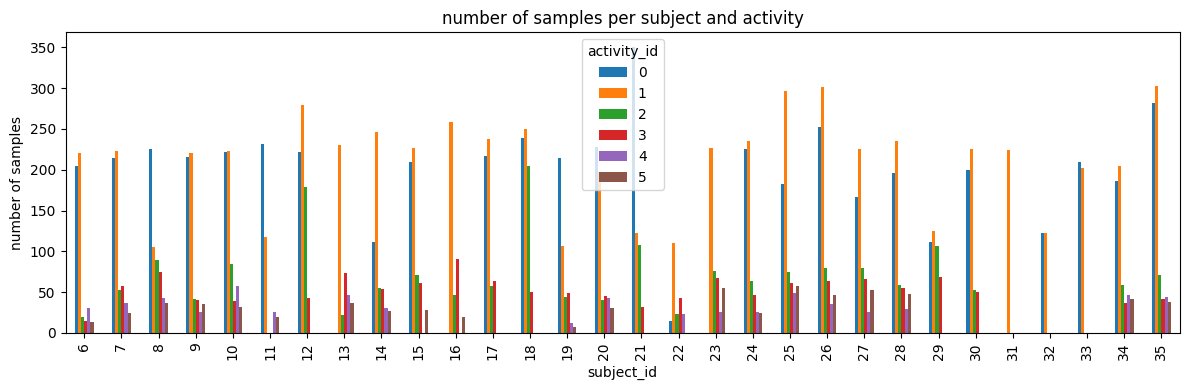

2025-10-23 17:03:58,921 - whar-datasets - INFO - Running DownloadingStep
2025-10-23 17:03:58,921 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-10-23 17:03:58,921 - whar-datasets - INFO - Hash is up to date
2025-10-23 17:03:58,922 - whar-datasets - INFO - Running ParsingStep
2025-10-23 17:03:58,922 - whar-datasets - INFO - Checking hash for ParsingStep
2025-10-23 17:03:58,923 - whar-datasets - INFO - Hash is up to date
2025-10-23 17:03:58,923 - whar-datasets - INFO - Running WindowingStep
2025-10-23 17:03:58,924 - whar-datasets - INFO - Checking hash for WindowingStep
2025-10-23 17:03:58,925 - whar-datasets - INFO - Hash is up to date
2025-10-23 17:03:58,925 - whar-datasets - INFO - Loading windowing
2025-10-23 17:03:58,933 - whar-datasets - INFO - activity_ids from 0 to 5
2025-10-23 17:03:58,933 - whar-datasets - INFO - subject_ids from 0 to 35
2025-10-23 17:03:58,935 - whar-datasets - INFO - train: 17915 | test: 4493
2025-10-23 17:03:58,936 - whar-datasets - INFO - R

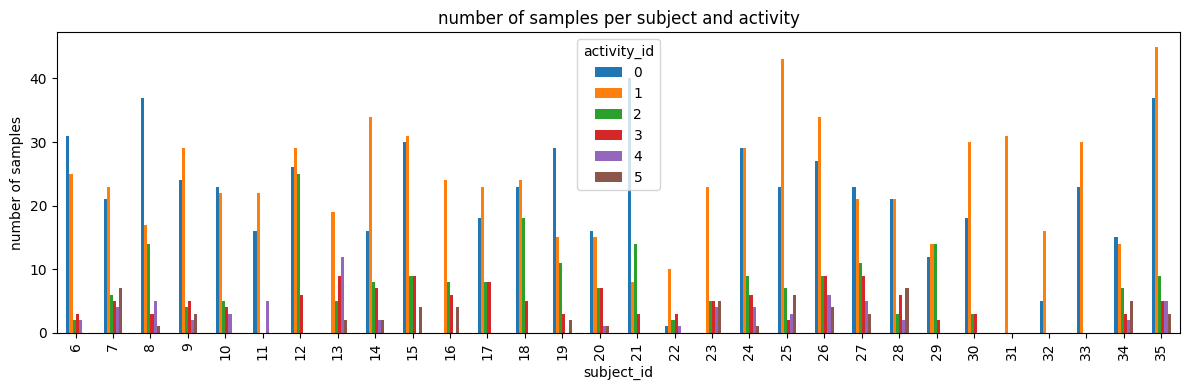

(6, 33, 51)
6


In [4]:
sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.TRAIN,
    transform=transform,
)

val_sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.VAL,
    transform=transform,
)

print(sampeable.shape)
print(sampeable.num_classes)

In [5]:
classifier = WISDMClassifier(
    in_c=sampeable.shape[0], num_classes=sampeable.num_classes, size=6144
).to(device)

# trainer = ClassifierTrainer(
#     classifier=classifier,
#     train_data=sampeable,
#     val_data=val_sampeable,
#     num_classes=sampeable.num_classes,
# )

trainer = EncoderTrainer(
    encoder=classifier,
    train_data=sampeable,
    val_data=val_sampeable,
    num_classes=sampeable.num_classes,
)

2025-10-23 16:50:32,864 - flow-matching - INFO - Training model with size: 3.081 MiB
Epoch 0/15: 100%|██████████| 500/500 [01:17<00:00,  6.46it/s, train_loss=0.420496]


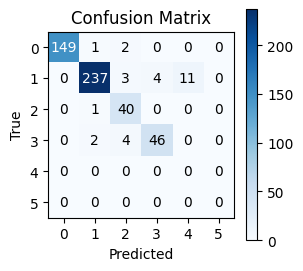

2025-10-23 16:51:51,182 - flow-matching - INFO - val loss: 0.9440000057220459, best val loss: 0.9440000057220459
Epoch 1/15: 100%|██████████| 500/500 [01:16<00:00,  6.56it/s, train_loss=0.157451]


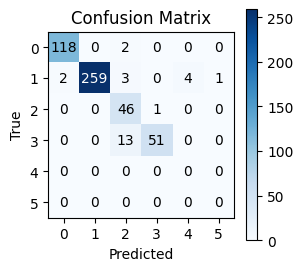

2025-10-23 16:53:08,269 - flow-matching - INFO - val loss: 0.9480000138282776, best val loss: 0.9480000138282776
Epoch 2/15: 100%|██████████| 500/500 [01:16<00:00,  6.57it/s, train_loss=0.092329]


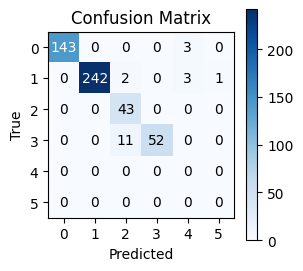

2025-10-23 16:54:25,200 - flow-matching - INFO - val loss: 0.9599999785423279, best val loss: 0.9599999785423279
Epoch 3/15: 100%|██████████| 500/500 [01:15<00:00,  6.63it/s, train_loss=0.059355]


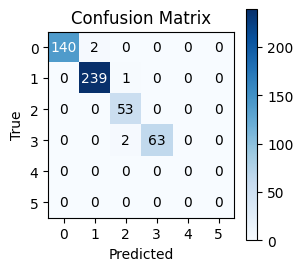

2025-10-23 16:55:41,449 - flow-matching - INFO - val loss: 0.9900000095367432, best val loss: 0.9900000095367432
Epoch 4/15:  17%|█▋        | 84/500 [00:12<01:04,  6.49it/s, train_loss=0.058250]


KeyboardInterrupt: 

In [8]:
state_dict = trainer.train(
    num_epochs=15,
    device=device,
    lr=3e-4,
    batch_size=64,
    steps_per_epoch=500,
    validate=True,
    patience=5,
    decreasing=False,
)

In [9]:
torch.save(classifier.state_dict(), "./models/classifier.pt")